Dataset Shape: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
Cleaned Dataset Shape: (397884, 9)


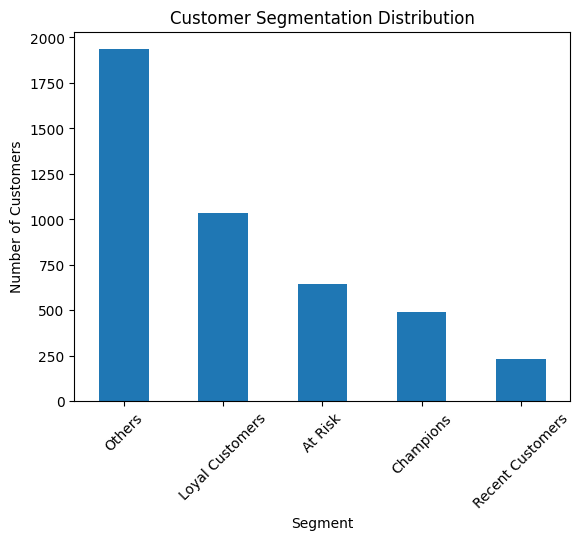


RFM Analysis Completed Successfully!

Segment Counts:
Segment
Others              1935
Loyal Customers     1033
At Risk              646
Champions            490
Recent Customers     234
Name: count, dtype: int64


In [3]:
# ==========================================
# TASK 15: CUSTOMER SEGMENTATION (RFM)
# DATASET: OnlineRetail.csv
# ==========================================

# 1️⃣ IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 2️⃣ UPLOAD FILE (if needed)
# files.upload()  # Uncomment if uploading manually

# 3️⃣ LOAD DATASET (DIRECTLY LOAD CSV)
df = pd.read_csv("OnlineRetail.csv.zip", encoding='ISO-8859-1')

print("Dataset Shape:", df.shape)
print(df.head())

# 4️⃣ DATA CLEANING

# Remove null CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove negative values
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Create Total Amount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Cleaned Dataset Shape:", df.shape)

# 5️⃣ CREATE REFERENCE DATE
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 6️⃣ CALCULATE RFM
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 7️⃣ CREATE RFM SCORES
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(int)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# 8️⃣ SEGMENT CUSTOMERS
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] == 4:
        return 'Recent Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 9️⃣ VISUALIZATION
plt.figure()
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segmentation Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

# 🔟 EXPORT FILE
rfm.to_csv("rfm_segments.csv")

print("\nRFM Analysis Completed Successfully!")
print("\nSegment Counts:")
print(rfm['Segment'].value_counts())
